# S19 · Backtest a trading rule, honestly

A friend's tip: **"Buy HDFC Bank when its 20-day average climbs above its 50-day
average. Sell when it drops below. Easy money."**

Before risking a rupee we ask one question: *does this rule actually make money?* The
only way to check is to replay the past. We pretend we followed the rule every day from
2019 to 2025 and add up what happened. That replay is a **backtest**, and by the end of
this notebook you will have built one from scratch and compared it with simply buying
and holding the stock.

**New here? Read this once.**

- New to Python? You can still do this whole notebook. Press the play button on each
  cell, top to bottom, and read the plain-English note above each one.
- New to "is this real or just luck"? `primers/hypothesis_testing_and_pvalues.md` is a
  ten-minute, picture-first read.
- Already confident with code or with trading? Look for the cells marked
  **Stretch (optional)** near the end.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup

On **Google Colab**, run the next cell once. On your **own machine** you already
installed everything with `uv`, so it does nothing there.

In [1]:
# This notebook uses numpy, pandas and matplotlib, which Colab already ships.
print("Setup complete - nothing to install.")

Setup complete - nothing to install.


## Step 1 — load the prices

Daily closing prices of HDFC Bank and ICICI Bank on the NSE, January 2019 to December
2025. They were downloaded once with
`yf.download(["HDFCBANK.NS", "ICICIBANK.NS"], start="2019-01-01", end="2026-01-01", auto_adjust=True)`
and saved, so everyone gets exactly the numbers on the slides, with or without internet.

In [2]:
from pathlib import Path
import numpy as np                 # fast maths on lists of numbers
import pandas as pd                # tables of data with dates
import matplotlib.pyplot as plt    # charts

# Where the saved prices live: next to this notebook, or on the course website.
local_copy = Path("../data/hdfc_icici_2019_2025.csv")
website_copy = ("https://girishmkulkarni.github.io/applied-maths-in-industry-site/"
                "sessions/S19/data/hdfc_icici_2019_2025.csv")

if local_copy.exists():
    prices = pd.read_csv(local_copy, index_col=0, parse_dates=True)
else:
    prices = pd.read_csv(website_copy, index_col=0, parse_dates=True)

print("days of prices:", len(prices))
print("from", prices.index[0].date(), "to", prices.index[-1].date())
prices.tail()

days of prices: 1730
from 2019-01-01 to 2025-12-31


,HDFCBANK,ICICIBANK
Date,,
2025-12-24,980.9752,1348.4321
2025-12-26,975.9582,1339.1106
2025-12-29,975.5647,1332.0701
2025-12-30,974.7778,1331.2766
2025-12-31,975.0729,1331.6733


## Step 2 — always look at the price first

Before any rule, plot the price and just look. This is what our rule has to trade.

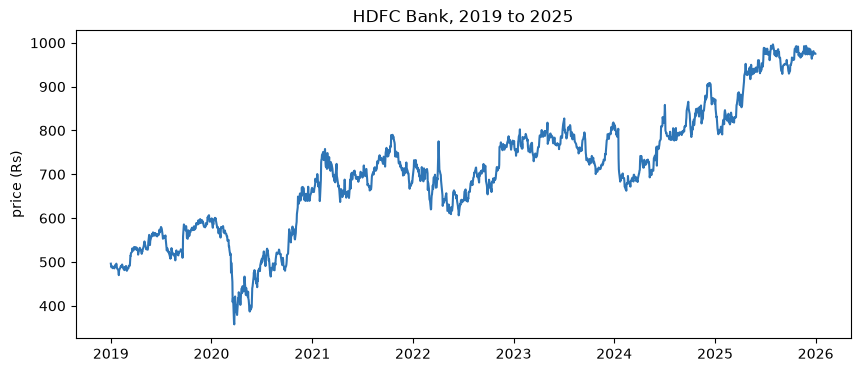

In [3]:
price = prices["HDFCBANK"]     # HDFC Bank's daily closing price

plt.figure(figsize=(10, 4))
plt.plot(price.index, price.values, color="#2E75B6")
plt.ylabel("price (Rs)")
plt.title("HDFC Bank, 2019 to 2025")
plt.show()

## Step 3 — a moving average, by hand first

A **moving average** is the ordinary average of the last few closing prices. Each day it
slides forward: drop the oldest price, add the newest.

Here are HDFC Bank's first four closes of 2025, and a 3-day average worked out by hand.
Check the numbers with a calculator.

In [4]:
first_days = price.loc["2025-01-01":"2025-01-07"].iloc[:4].round(1)
print(first_days)

print("\n3-day average on 3 Jan:", round((first_days.iloc[0] + first_days.iloc[1] + first_days.iloc[2]) / 3, 1))
print("3-day average on 6 Jan:", round((first_days.iloc[1] + first_days.iloc[2] + first_days.iloc[3]) / 3, 1))

# pandas does exactly this with rolling(3).mean()
print("\npandas agrees:")
print(first_days.rolling(3).mean().round(1))

Date
2025-01-01    865.2
2025-01-02    870.5
2025-01-03    848.9
2025-01-06    830.1
Name: HDFCBANK, dtype: float64

3-day average on 3 Jan: 861.5
3-day average on 6 Jan: 849.8

pandas agrees:
Date
2025-01-01      NaN
2025-01-02      NaN
2025-01-03    861.5
2025-01-06    849.8
Name: HDFCBANK, dtype: float64


## Step 4 — the fast and the slow average

Our rule uses a **fast** 20-day average (reacts quickly) and a **slow** 50-day average
(reacts slowly). We draw both for 2023–24 so the lines are easy to see.

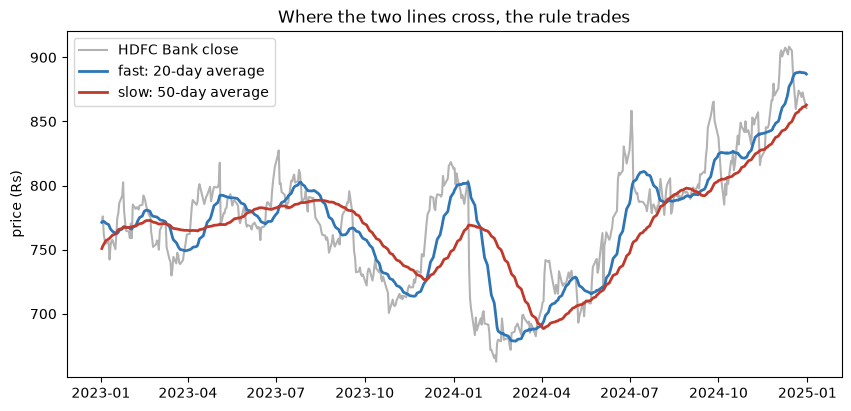

In [5]:
fast = price.rolling(20).mean()     # 20-day average
slow = price.rolling(50).mean()     # 50-day average

window = slice("2023-01-01", "2024-12-31")
plt.figure(figsize=(10, 4.5))
plt.plot(price.loc[window], color="grey", alpha=0.6, label="HDFC Bank close")
plt.plot(fast.loc[window], color="#2E75B6", linewidth=2, label="fast: 20-day average")
plt.plot(slow.loc[window], color="#C0392B", linewidth=2, label="slow: 50-day average")
plt.ylabel("price (Rs)")
plt.title("Where the two lines cross, the rule trades")
plt.legend()
plt.show()

## Step 5 — the rule as one number a day

The whole rule in words:

- fast average **above** slow average → **own** the stock (position = 1)
- fast average **below** slow average → stay in **cash** (position = 0)

`(fast > slow)` is True or False each day; `.astype(int)` turns that into 1 or 0.

In [6]:
position = (fast > slow).astype(int)     # 1 = own the stock, 0 = cash

print("days owning the stock:", position.sum())
print("days in cash         :", (position == 0).sum())
print("buy or sell days     :", int(position.diff().abs().sum()))

days owning the stock: 1078
days in cash         : 652
buy or sell days     : 44


## Step 6 — replay five days by hand

Two rules make every backtest:

1. **Rule's return today = the position you held today × the stock's return today.**
2. The position you hold today is **yesterday's** signal, because you only learn the
   signal after the close. In pandas, `position.shift(1)` moves every signal one day later.

Here are five days around the first buy signal of 2025. Watch the day the signal
flips to 1: we still earn nothing that day, because we are still holding yesterday's
position (cash). We start earning the next day.

In [7]:
stock_return = price.pct_change()          # today's % change in price
held = position.shift(1)                   # yesterday's signal = what we hold today
strategy_return = held * stock_return      # earn the stock's return only when we hold it

# Find the first buy of 2025 and show a few days around it
first_buy = position.loc["2025"][position.loc["2025"].diff() == 1].index[0]
start = price.index.get_loc(first_buy) - 1
days = price.index[start:start + 5]

table = pd.DataFrame({
    "close": price[days].round(1),
    "stock return %": (100 * stock_return[days]).round(2),
    "signal today": position[days],
    "held today": held[days].astype(int),
    "rule's return %": (100 * strategy_return[days]).round(2),
    "Rs 1 becomes": (1 + strategy_return[days]).cumprod().round(4),
})
table

,close,stock return %,signal today,held today,rule's return %,Rs 1 becomes
Date,,,,,,
2025-02-27,825.4,1.09,0,0,0.00,1.0000
2025-02-28,840.7,1.86,1,0,0.00,1.0000
2025-03-03,825.8,-1.78,1,1,-1.78,0.9822
2025-03-04,829.9,0.50,1,1,0.50,0.9871
2025-03-05,820.2,-1.17,1,1,-1.17,0.9755


## Step 7 — the whole backtest

Now let the computer do every day from 2019 to 2025. Each day ₹1 grows by
`(1 + that day's return)`, so `.prod()` of all those growth factors is what ₹1 became.
We do the same for simply holding the stock, which is the thing to beat.

In [8]:
rule = (1 + strategy_return).prod()     # multiply up every day's growth
hold = (1 + stock_return).prod()

print("Rs 1 following the rule became:", round(rule, 2))
print("Rs 1 just holding HDFC became :", round(hold, 2))

Rs 1 following the rule became: 1.05
Rs 1 just holding HDFC became : 1.97


## Step 8 — the equity curves

The **equity curve** is the running value of ₹1. `cumprod()` is the running version of
`prod()`: it gives the value on every day, not only the last one.

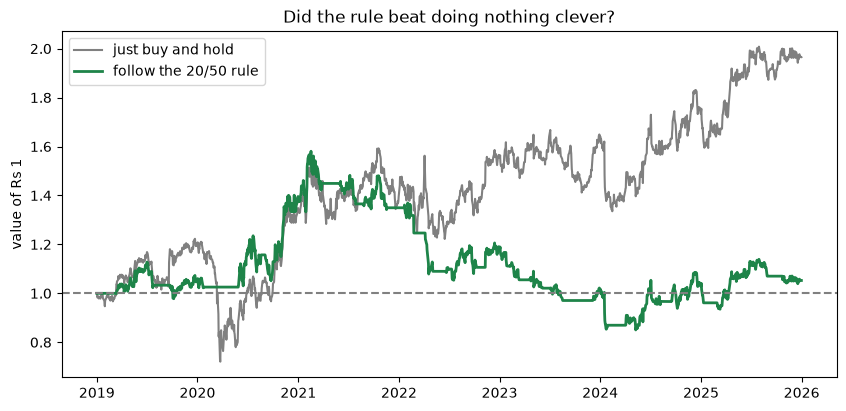

In [9]:
rule_curve = (1 + strategy_return.fillna(0)).cumprod()
hold_curve = (1 + stock_return.fillna(0)).cumprod()

plt.figure(figsize=(10, 4.5))
plt.plot(hold_curve, color="grey", label="just buy and hold")
plt.plot(rule_curve, color="#1E8449", linewidth=2, label="follow the 20/50 rule")
plt.axhline(1, color="grey", linestyle="--")
plt.ylabel("value of Rs 1")
plt.title("Did the rule beat doing nothing clever?")
plt.legend()
plt.show()

## Step 9 — judge more than the final number

Three numbers traders always report:

- **yearly return**: the steady growth rate that would give the same final value;
- **Sharpe ratio** (from S16): average daily return ÷ its standard deviation, scaled to a
  year by √252. Return per unit of bumpiness;
- **worst fall** or **maximum drawdown** (from S17): the deepest drop below a previous high.

In [10]:
years = (price.index[-1] - price.index[0]).days / 365.25

def report(daily_returns, name):
    r = daily_returns.fillna(0)
    curve = (1 + r).cumprod()
    yearly = curve.iloc[-1] ** (1 / years) - 1
    sharpe = r.mean() / r.std() * np.sqrt(252)
    worst_fall = (curve / curve.cummax() - 1).min()
    print(f"{name:14s} yearly {100 * yearly:5.1f}%   Sharpe {sharpe:5.2f}   worst fall {100 * worst_fall:5.0f}%")

report(strategy_return, "the rule")
report(stock_return, "buy and hold")

the rule       yearly   0.7%   Sharpe  0.13   worst fall   -46%
buy and hold   yearly  10.1%   Sharpe  0.52   worst fall   -41%


The honest verdict: on HDFC Bank from 2019 to 2025 the rule roughly broke even while
holding the stock nearly doubled the money, and its worst fall was no shallower. The rule
is not a money machine. That is a perfectly good result for a backtest: it told us the
truth before we risked anything.

### Stretch (optional) — try other window lengths

Skip this if you are new to code. Change `20` and `50` to other numbers, say `10` and
`100`, rerun the steps, and see how the answer moves. Keep a count of how many you try:
notebook 02 explains why that count matters.

In [11]:
# Stretch: any two window lengths you like
f, s = 10, 100
pos2 = (price.rolling(f).mean() > price.rolling(s).mean()).astype(int)
print(f"{f}/{s} rule: Rs 1 became", round((1 + pos2.shift(1) * stock_return).prod(), 2))

10/100 rule: Rs 1 became 1.0


## Your turn

Run the same 20/50 backtest on **ICICI Bank** instead: set `price = prices["ICICIBANK"]`
and rerun from Step 4. Does the rule beat buy and hold there? By how much?

In [12]:
# Your code here: the 20/50 rule on ICICI Bank.

## What you just did

You turned a stock tip into a rule, the rule into one number a day, and replayed seven
years of real prices with it: by hand for five days, then for all of them. The line that
kept it honest was `position.shift(1)`: you only ever act on a signal the day after you
see it. Notebook 02 breaks this backtest on purpose, to show how easily a backtest lies.